In [8]:
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

import wandb
from wandb_util import extract_run_savepoint
from nRTD.rtd_fitting import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import matplotlib as mpl
import ICIW_Plots

plt.style.use(["ICIWstyle"])
plt.rcParams.update(
    {
        "font.size": 7,
    }
)

In [ ]:
# run_ids = [
#     "gt8kjb40",  #  75 ml/min, 25 s
#     "xr9mt718",  # 250 ml/min, 25 s
#     "p7izg8mz",  # 300 ml/min, 25 s
# ]

import ICIW_Plots.colors


run_ids = [
    "j11icqt4",  #  75 ml/min, 22.5 s
    "d8wvd8ka",  # 250 ml/min, 22.5 s
    "f77tt4fg",  # 300 ml/min, 22.5 s
]

V_dots = [
    r"$\dot{V}_\mathrm{N}=75\;\mathrm{mL}\;\mathrm{min}^{-1}$",
    r"$\dot{V}_\mathrm{N}=250\;\mathrm{mL}\;\mathrm{min}^{-1}$",
    r"$\dot{V}_\mathrm{N}=300\;\mathrm{mL}\;\mathrm{min}^{-1}$",
]

"(0.11764705882352944, 1.0, 0.7735294117647058)"
"(0.11764705882352944, 0.5647058823529412, 1.0)"
"(0.3323529411764701, 0.11764705882352944, 1.0)"


In [10]:
names = []
paths = []
for run_id in run_ids:
    name, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{run_id}")
    names.append(name)
    paths.append(ckpt_path)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


In [11]:
Es = []
ts = []
for name, path in zip(names, paths):
    print(name, path)
    model = RTDModule.load_from_checkpoint(path)
    Es.append(model.net.E[0])
    ts.append(model.net.conv_layers[0].t_kernel.detach().numpy())

rose-sweep-4 d:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_001\visualization\artifacts\model-j11icqt4-v0\model.ckpt
logical-sweep-4 d:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_001\visualization\artifacts\model-d8wvd8ka-v0\model.ckpt
treasured-sweep-4 d:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_001\visualization\artifacts\model-f77tt4fg-v0\model.ckpt


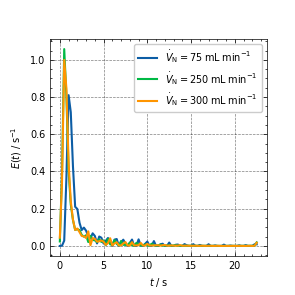

In [12]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$E(t)\;/\; \mathrm{s}^{-1}$",
)

for V_dot, E, t in zip(V_dots, Es, ts):
    ax.plot(t, E, label=V_dot)

ax.legend()

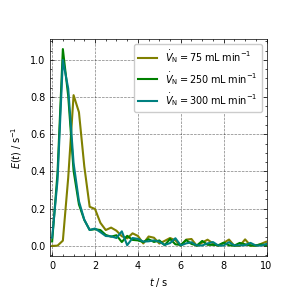

In [ ]:
ccycler = ICIW_Plots.colors.adjacent_cycler(
    mpl.colors.to_rgb(mpl.colors.CSS4_COLORS["green"]), n=3, phi=60
)

fig = ICIW_Plots.figure()


with plt.rc_context({"axes.prop_cycle": ccycler}):
    ax = ICIW_Plots.make_square_ax(
        fig,
        ax_width=5.5 * ICIW_Plots.cm2inch,
        left_h=0.5,
        xlabel=r"$t \;/\; \mathrm{s}$",
        ylabel=r"$E(t)\;/\; \mathrm{s}^{-1}$",
        xlim=(-0.1, 10),
    )
    for V_dot, E, t in zip(V_dots, Es, ts):

        ax.plot(t, E, label=V_dot)



ax.legend()


plt.savefig("RTD_capilary_1Comp.svg")


plt.savefig("RTD_capilary_1Comp.png", dpi=600)